# **🏡 Project: The House Price Engine 📈**

## **🌟 What are we building?**

Welcome to the **House Price Prediction Project**! Pricing real estate is notoriously tricky. It’s a mix of hard facts (square footage) and soft variables (neighborhood vibes). For banks, buyers, and platforms like Zillow, getting this wrong by even 5% can mean leaving tens of thousands of dollars on the table.

In this project, we are stepping into the shoes of a **Data Scientist** to build a machine learning model that takes the guesswork out of property values. We will use `pandas` to wrangle messy raw housing data and build a predictive engine that accurately prices homes based on their actual features.

---

## **🗺️ The Roadmap: How we get it done**

We aren't just throwing data at an algorithm and hoping for the best. We’re building a clean, step-by-step pipeline across four key phases:

* **1. Digging into the Data (EDA) 🔍**
  * We'll use `pandas` to pull in our CSV files, check out what data types we're dealing with, and hunt down missing values. 
  * We'll look at the distribution of house prices to see if luxury homes are skewing our numbers, and find out which variables actually correlate with a higher price tag.

* **2. Cleaning & Feature Engineering 🛠️**
  * Raw data is never perfect. We will use `pandas` methods to fill in missing gaps and drop weird outliers (like a massive mansion sold for dirt cheap).
  * We'll create smarter features that the model can understand—like combining individual porch and deck metrics into a single "Total Outdoor Space" variable, or calculating exactly how old a house was the year it was sold.

* **3. Training the Models 🤖**
  * Because we are predicting a continuous number (price), this is a **Regression** problem.
  * We’ll start with a straightforward linear model to set a baseline score. Once that’s locked in, we’ll unleash heavy-hitting gradient-boosted trees like **XGBoost** and **LightGBM** to handle the complex, non-linear relationships in the data.

* **4. Keeping Evaluation Realistic 📊**
  * We will test our models using **RMSLE** (Root Mean Squared Log Error). Why? Because a \$20,000 mistake on a \$100,000 starter home is a disaster, but a \$20,000 mistake on a \$2,000,000 mansion is practically a rounding error. Log error keeps our penalties fair across all price brackets.

---

## **💡 Coding Standards (No Sloppy Notebooks)**

We are writing code that looks like it belongs in a production environment, not just a sandbox:

* **Readable & Modular:** No giant blocks of messy code. We’ll write clean, reusable python functions with clear descriptions.
* **Bulletproof Integrity:** We will explicitly validate our data shapes and types using `pandas` before passing anything to our machine learning models. 
* **Scalable Thinking:** The logic we write for this dataset will be clean enough to easily scale up to enterprise-level data down the road.

### 🚀 Automated Data Ingestion

To ensure maximum reproducibility and maintain clean versioning, we pull the dataset directly using Kaggle's tools. This automated process fetches the raw housing feature records—tracking structural properties, location metrics, and sales history—directly into our environment.

* **Dataset Credit:** Vedat Gül via Kaggle (*House Prices Prediction / Advanced Regression Techniques*).
* **Source Notebook/Data:** [Kaggle Notebook Link](https://www.kaggle.com/datasets/fratzcan/usa-house-prices)

### 📥 Loading the Dataset and Libraries

Before we start, we need to install the necessary Python libraries and **load the dataset**.


In [183]:
# Install the required libraries
%pip install kagglehub pandas numpy matplotlib seaborn scikit-learn lightgbm xgboost sweetviz -q
%pip install ucimlrepo -q

# Install and update the watermark package to display environment and library version information
%pip install -q -U watermark

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


### 📥 Loading the Dataset and Libraries

Before we start, we need to install the necessary Python libraries and **load the dataset**.


In [184]:
# ✅ CORE
import numpy as np
import pandas as pd
import os
import sweetviz as sv

# ✅ Visualization (EDA)
import matplotlib.pyplot as plt
plt.style.use('dark_background')
import seaborn as sns
import kagglehub
# Step 1: Apply the global dark background style sheet


# ✅ Preprocessing
from sklearn.impute import SimpleImputer

# ✅ Models
from sklearn.linear_model import LinearRegression, Ridge


# ✅ Evaluation
from sklearn.metrics import mean_squared_error

# ✅ Validation
from sklearn.model_selection import cross_val_score, train_test_split, KFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import Ridge

# ✅ Advanced models
import xgboost as xgb
import lightgbm as lgb

In [185]:
# Load the watermark extension to log the environment state
%reload_ext watermark

# Display professional metadata tracking our data engineering stack
%watermark -a "Maykon - 🏡 The House Price Engine" -d -u -v -p pandas,numpy,matplotlib,seaborn,scikit-learn,xgboost,lightgbm

Author: Maykon - 🏡 The House Price Engine

Last updated: 2026-06-22

Python implementation: CPython
Python version       : 3.13.7
IPython version      : 9.14.1

pandas      : 3.0.3
numpy       : 2.4.6
matplotlib  : 3.10.9
seaborn     : 0.13.2
scikit-learn: 1.9.0
xgboost     : 3.3.0
lightgbm    : 4.6.0



In [186]:
# Download latest version
path = kagglehub.dataset_download("fratzcan/usa-house-prices")

print("📦 Path to dataset files:", path)

📦 Path to dataset files: C:\Users\LarTI\.cache\kagglehub\datasets\fratzcan\usa-house-prices\versions\1


In [187]:
# --- LOCATING AND READING THE CSV ---
# List out all files inside the downloaded repository path to spot the target file
all_files = os.listdir(path)
print("📂 Files discovered in directory:", all_files)

# Filter out all CSV files dynamically
csv_files = [file for file in all_files if file.endswith('.csv')]

if len(csv_files) == 0:
    raise FileNotFoundError("❌ Critical Error: No CSV files found in the downloaded folder!")
else:
    # Grab the primary CSV file found
    csv_filename = csv_files[0]
    full_csv_path = os.path.join(path, csv_filename)
    print(f"🎯 Target CSV located: {csv_filename}")

📂 Files discovered in directory: ['USA Housing Dataset.csv']
🎯 Target CSV located: USA Housing Dataset.csv


In [188]:
# Ingest the dataset into a pandas DataFrame
df = pd.read_csv(full_csv_path)
print(f"✅ Dataset successfully loaded! Shape: {df.shape[0]} rows, {df.shape[1]} columns.")

✅ Dataset successfully loaded! Shape: 4140 rows, 18 columns.


In [189]:
# Display the first 5 records to see our column properties and labels
df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-09 00:00:00,376000.0,3.0,2.00,1340,1384,3.0,0,0,3,1340,0,2008,0,9245-9249 Fremont Ave N,Seattle,WA 98103,USA
1,2014-05-09 00:00:00,800000.0,4.0,3.25,3540,159430,2.0,0,0,3,3540,0,2007,0,33001 NE 24th St,Carnation,WA 98014,USA
2,2014-05-09 00:00:00,2238888.0,5.0,6.50,7270,130017,2.0,0,0,3,6420,850,2010,0,7070 270th Pl SE,Issaquah,WA 98029,USA
3,2014-05-09 00:00:00,324000.0,3.0,2.25,998,904,2.0,0,0,3,798,200,2007,0,820 NW 95th St,Seattle,WA 98117,USA
4,2014-05-10 00:00:00,549900.0,5.0,2.75,3060,7015,1.0,0,0,5,1600,1460,1979,0,10834 31st Ave SW,Seattle,WA 98146,USA


In [190]:
df.sample(15) # Random 15 rows

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
4019,2014-06-11 00:00:00,0.0,5.0,2.00,1910,7200,1.0,0,0,4,1110,800,1951,1999,11620-11698 57th Ave S,Seattle,WA 98178,USA
199,2014-05-14 00:00:00,525000.0,3.0,1.75,1600,6120,1.5,0,0,3,1600,0,1924,2011,7557 35th Ave NE,Seattle,WA 98115,USA
1485,2014-06-05 00:00:00,798000.0,3.0,3.50,3590,6402,2.0,0,0,3,3590,0,1999,0,20555 NE 27th Pl,Sammamish,WA 98074,USA
2777,2014-06-24 00:00:00,325000.0,3.0,1.00,850,6906,1.0,0,0,3,850,0,1948,1994,15812 14th Avenue Northeast,Shoreline,WA 98155,USA
2157,2014-06-16 00:00:00,468500.0,3.0,2.50,1350,1186,2.0,0,0,3,1120,230,2007,0,6724 Alonzo Ave NW,Seattle,WA 98117,USA
1608,2014-06-06 00:00:00,279000.0,5.0,2.50,2690,5557,2.0,0,0,3,2690,0,2012,1912,6421 S 124th St,Seattle,WA 98178,USA
1054,2014-05-28 00:00:00,510000.0,4.0,1.50,2040,8800,1.0,0,0,4,1020,1020,1961,2001,1518 150th Ave SE,Bellevue,WA 98007,USA
522,2014-05-20 00:00:00,440000.0,2.0,1.75,1300,4000,2.0,0,0,3,1300,0,1948,1994,5501 37th Ave NE,Seattle,WA 98105,USA
2763,2014-06-24 00:00:00,139000.0,2.0,1.00,690,5280,1.0,0,0,4,690,0,1942,1982,755 Dayton Ave NE,Renton,WA 98056,USA
2260,2014-06-17 00:00:00,286800.0,3.0,2.50,1413,3600,2.0,0,0,3,1413,0,2011,0,20130 110th Terrace SE,Kent,WA 98031,USA


In [191]:
df.tail() #Displays the last 5 rows of the DataFrame df.

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
4135,2014-07-09 00:00:00,308166.666667,3.0,1.75,1510,6360,1.0,0,0,4,1510,0,1954,1979,501 N 143rd St,Seattle,WA 98133,USA
4136,2014-07-09 00:00:00,534333.333333,3.0,2.50,1460,7573,2.0,0,0,3,1460,0,1983,2009,14855 SE 10th Pl,Bellevue,WA 98007,USA
4137,2014-07-09 00:00:00,416904.166667,3.0,2.50,3010,7014,2.0,0,0,3,3010,0,2009,0,759 Ilwaco Pl NE,Renton,WA 98059,USA
4138,2014-07-10 00:00:00,203400.000000,4.0,2.00,2090,6630,1.0,0,0,3,1070,1020,1974,0,5148 S Creston St,Seattle,WA 98178,USA
4139,2014-07-10 00:00:00,220600.000000,3.0,2.50,1490,8102,2.0,0,0,4,1490,0,1990,0,18717 SE 258th St,Covington,WA 98042,USA


#### 🔎📊 Exploratory Data Analysis (EDA)

The investigation phase begins here. Before making any changes or feeding numbers into an algorithm, we dive deep into the data to uncover underlying market patterns, spot anomalies, and catch structural flaws 💡. 

Using statistical measures and targeted data visualizations 📈 (like plotting the distribution of house prices to check for luxury outliers or mapping correlations between square footage and final sale value), we analyze how different home characteristics behave. This critical health check ensures we understand exactly what the data is telling us before we write a single line of feature engineering or modeling code 🛠️.

In [192]:
# Information about the dataframe
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4140 entries, 0 to 4139
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           4140 non-null   str    
 1   price          4140 non-null   float64
 2   bedrooms       4140 non-null   float64
 3   bathrooms      4140 non-null   float64
 4   sqft_living    4140 non-null   int64  
 5   sqft_lot       4140 non-null   int64  
 6   floors         4140 non-null   float64
 7   waterfront     4140 non-null   int64  
 8   view           4140 non-null   int64  
 9   condition      4140 non-null   int64  
 10  sqft_above     4140 non-null   int64  
 11  sqft_basement  4140 non-null   int64  
 12  yr_built       4140 non-null   int64  
 13  yr_renovated   4140 non-null   int64  
 14  street         4140 non-null   str    
 15  city           4140 non-null   str    
 16  statezip       4140 non-null   str    
 17  country        4140 non-null   str    
dtypes: float64(4), int6

In [193]:
df.describe(include='all').T  # Generates descriptive statistics for all numeric columns in your DataFrame.

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
date,4140,68,2014-06-23 00:00:00,142,NaN,NaN,NaN,NaN,NaN,NaN,NaN
price,4140.0,NaN,NaN,NaN,553062.877289,583686.452245,0.0,320000.0,460000.0,659125.0,26590000.0
bedrooms,4140.0,NaN,NaN,NaN,3.400483,0.903939,0.0,3.0,3.0,4.0,8.0
bathrooms,4140.0,NaN,NaN,NaN,2.163043,0.784733,0.0,1.75,2.25,2.5,6.75
sqft_living,4140.0,NaN,NaN,NaN,2143.638889,957.481621,370.0,1470.0,1980.0,2620.0,10040.0
sqft_lot,4140.0,NaN,NaN,NaN,14697.638164,35876.838123,638.0,5000.0,7676.0,11000.0,1074218.0
floors,4140.0,NaN,NaN,NaN,1.51413,0.534941,1.0,1.0,1.5,2.0,3.5
waterfront,4140.0,NaN,NaN,NaN,0.007488,0.086219,0.0,0.0,0.0,0.0,1.0
view,4140.0,NaN,NaN,NaN,0.246618,0.790619,0.0,0.0,0.0,0.0,4.0
condition,4140.0,NaN,NaN,NaN,3.452415,0.678533,1.0,3.0,3.0,4.0,5.0


### 🧹 Data Cleaning - processing and handling of missing data.

After loading the dataset and reviewing its structure with 'df.info()' and, the next step is to identify missing values in the dataset.  

We use:

In [194]:
df.isna().sum()  # You can also use df.isnull().sum() — both do the same thing

date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
street           0
city             0
statezip         0
country          0
dtype: int64

In [195]:
# Drop useless columns from the dataframe
df = df.drop(columns=['country', 'street', 'city'])

In [196]:
df.drop_duplicates(inplace=True) # Remove duplicate rows from the DataFrame df.
print("Number of duplicate rows Now:", df.duplicated().sum()) # After dropping duplicates, check again to confirm that there are no duplicate rows remaining in the DataFrame df.

Number of duplicate rows Now: 0


In [197]:
# this code will standardize the column names by replacing spaces with underscores, converting all characters to lowercase,
# and stripping any leading or trailing whitespace from the column names in the DataFrame df. This is a common practice to ensure that column names 
# are consistent and easier to work with in code.
df.columns = (df.columns.str.replace(' ', '_').str.lower().str.strip())

In [198]:
# Calculate absolute counts and percentages of missing data per column
missing_counts = df.isna().sum()
missing_percentages = (df.isna().sum() / len(df)) * 100

# Combine the results into a clean summary table
missing_data_summary = pd.DataFrame({
    'Total Missing': missing_counts,
    'Percentage (%)': missing_percentages
})

# Filter out the columns that are 100% clean so we can focus on the trouble areas
trouble_columns = missing_data_summary[missing_data_summary['Total Missing'] > 0].sort_values(by='Total Missing', ascending=False)

if trouble_columns.empty:
    print("✨ Clean Data Check: No missing values found anywhere in the dataset!")
else:
    print(f"⚠️ Found {len(trouble_columns)} columns with missing data.")
    print(trouble_columns)

✨ Clean Data Check: No missing values found anywhere in the dataset!


The goal of this preprocessing step is to improve data quality by eliminating unrealistic values and extreme price outliers that could negatively impact model training and lead to biased or unstable predictions. 
Performing this cleaning before the train/test split ensures that both datasets are drawn from the same cleaned distribution.

In [199]:
# Step 1: Remove impossible prices — a house cannot cost $0
before = df.shape[0]
df = df[df['price'] > 0]
print(f"Removed {before - df.shape[0]} houses with $0 price")

# Step 2: Remove extreme price outliers using IQR method
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

before = df.shape[0]
df = df[(df['price'] >= lower_bound) & (df['price'] <= upper_bound)]
print(f"Removed {before - df.shape[0]} extreme price outliers")
print(f"Price range after cleaning: ${df['price'].min():,.0f} — ${df['price'].max():,.0f}")
print(f"Final shape: {df.shape}")

Removed 49 houses with $0 price
Removed 216 extreme price outliers
Price range after cleaning: $7,800 — $1,160,000
Final shape: (3875, 15)


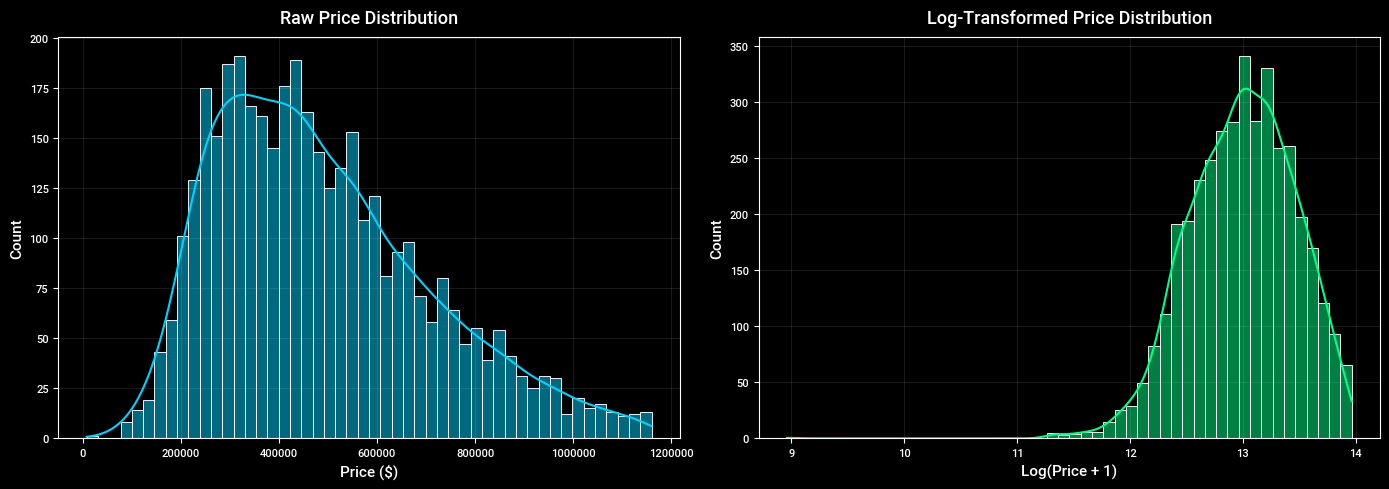

In [200]:
# This plot will show us the distribution of the target variable (price) in its raw form and after applying a log transformation to handle skewness.
#  It helps us understand the spread and central tendency of the price data, which is crucial for modeling decisions.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- PLOT 1: RAW PRICE DISTRIBUTION ---
# Step 3: Draw the original price distribution chart
sns.histplot(
    df['price'], 
    bins=50, 
    kde=True, 
    color='#00d2ff',  # Bright neon blue for dark contrast
    ax=axes[0]
)
axes[0].set_title('Raw Price Distribution', fontsize=13, pad=10, color='#ffffff')
axes[0].set_xlabel('Price ($)', fontsize=11)
axes[0].set_ylabel('Count', fontsize=11)
axes[0].grid(True, alpha=0.1)  # Keep grid lines very subtle

# --- PLOT 2: LOG PRICE DISTRIBUTION ---
# Step 4: Draw the log-transformed price distribution chart
sns.histplot(
    np.log1p(df['price']), 
    bins=50, 
    kde=True, 
    color='#00ff87',  # Vibrant neon green
    ax=axes[1]
)
axes[1].set_title('Log-Transformed Price Distribution', fontsize=13, pad=10, color='#ffffff')
axes[1].set_xlabel('Log(Price + 1)', fontsize=11)
axes[1].set_ylabel('Count', fontsize=11)
axes[1].grid(True, alpha=0.1)

# Step 5: Adjust padding, render the dark canvas layout, and clear memory
plt.tight_layout()
plt.show()

# Step 6: Optional - Reset to default if you have other standard charts later
# plt.style.use('default')

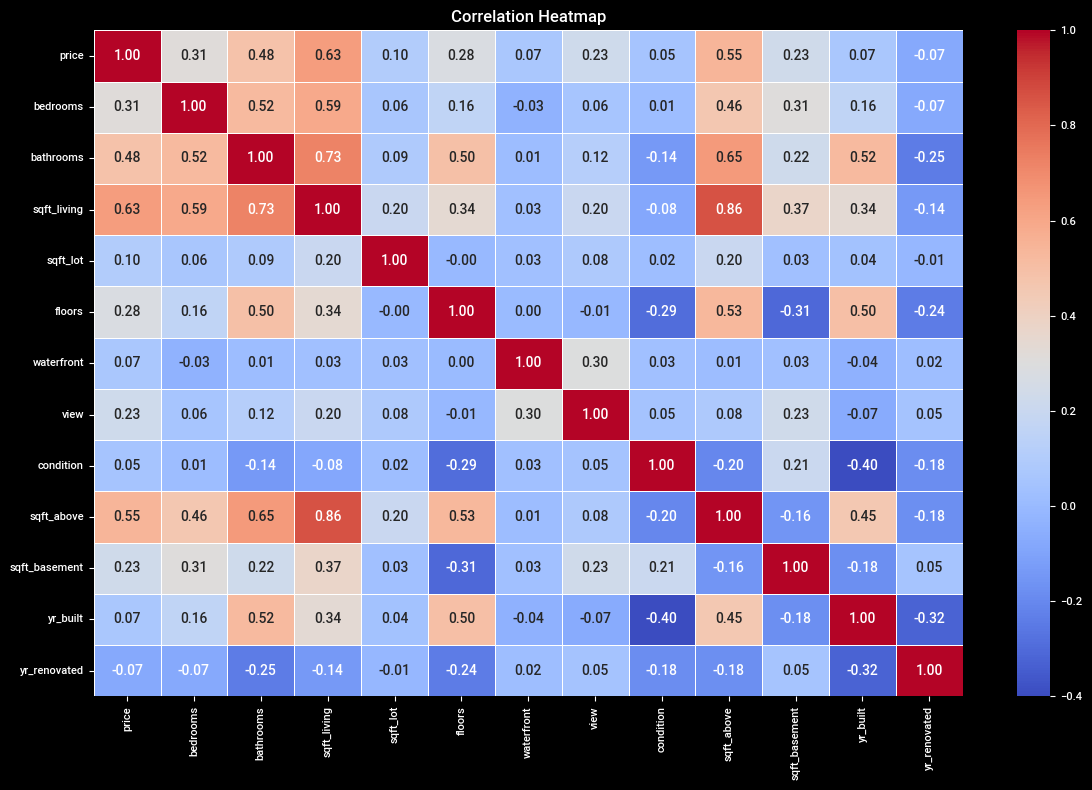

In [201]:
# --- CORRELATION HEATMAP ---
# used to visualize the correlation between numerical features in the dataset. 
# It helps identify which features are strongly correlated with the target variable (price) and with each other, guiding feature selection and engineering 
# decisions for modeling.
plt.figure(figsize=(12, 8))
sns.heatmap(
    df.select_dtypes(include='number').corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5
)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

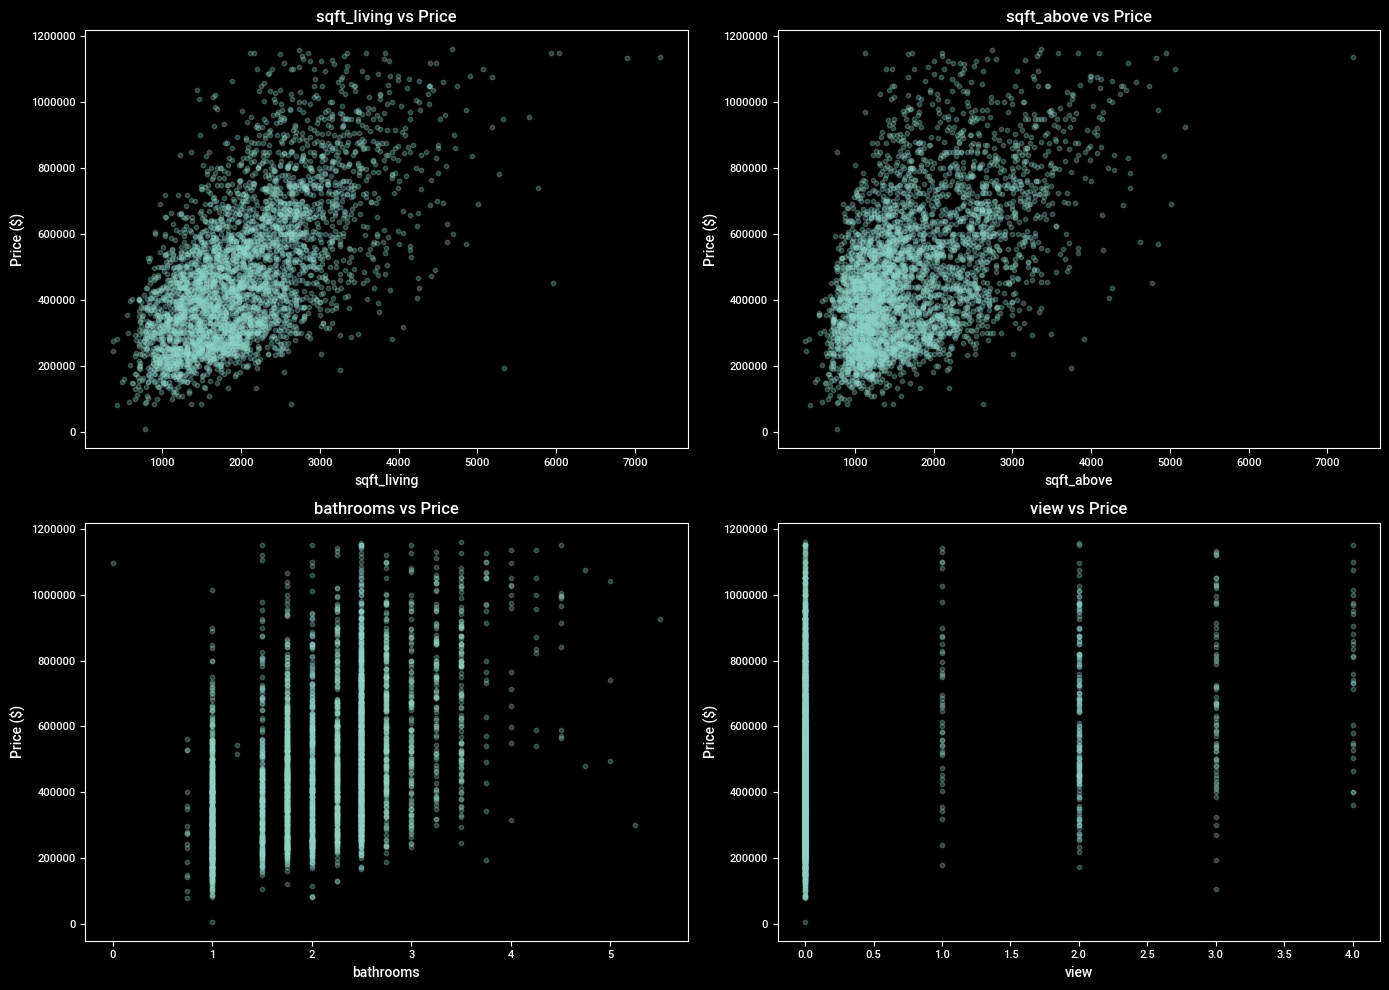

In [202]:
# This scatter plot grid will help us visually confirm the strength and nature of the relationships between the top features and the target variable (price).
top_features = ['sqft_living', 'sqft_above', 'bathrooms', 'view']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, feature in enumerate(top_features):
    axes[i].scatter(df[feature], df['price'], alpha=0.3, s=10)
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Price ($)')
    axes[i].set_title(f'{feature} vs Price')

plt.tight_layout()
plt.show()

In [203]:
#This will show the data types of each column in the DataFrame, which is crucial for understanding how to handle each feature during preprocessing and modeling.
df.dtypes

date                 str
price            float64
bedrooms         float64
bathrooms        float64
sqft_living        int64
sqft_lot           int64
floors           float64
waterfront         int64
view               int64
condition          int64
sqft_above         int64
sqft_basement      int64
yr_built           int64
yr_renovated       int64
statezip             str
dtype: object

In [204]:
report = sv.analyze(df, target_feat='price') # Generate a Sweetviz report analyzing the DataFrame df with 'price' as the target variable for insights into feature relationships and distributions.

# Render and write the interactive application directly to an HTML file
report.show_html('House_Prices_Report.html')

Done! Use 'show' commands to display/save.   |██████████| [100%]   00:01 -> (00:00 left)

Report House_Prices_Report.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


#### 🎯 Defining the data between Features (X) and Target (y)

In machine learning, we divide the dataset into:

- **Features (`X`)** → the input variables used to make the prediction.
- **Target variable (`y`)** → the outcome we want to predict.

For the dataset:

In [205]:
# Here we are separating the features (X) from the target variable (y). 
# The target variable is 'price', which indicates the price of a house. 
# The features (X) are all the other columns in the DataFrame df, which will be used to predict the target variable.
X = df.drop(columns=['price'])
y = df['price']

# This code snippet splits the dataset into training and testing sets.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [206]:
# This code makes it easy to identify which features are most influential in predicting house prices, allowing for more informed feature selection and engineering decisions.

# Separate numeric and categorical columns
numeric_features     = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X_train.select_dtypes(include=['object', 'category', 'str']).columns.tolist()

print(f"Numeric features ({len(numeric_features)}):")
print(numeric_features)
print()
print(f"Categorical features ({len(categorical_features)}):")
print(categorical_features)

Numeric features (12):
['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated']

Categorical features (2):
['date', 'statezip']


In [207]:
print(f"The final shape of our DataFrame: {df.shape[0]} rows, {df.shape[1]} columns.")

The final shape of our DataFrame: 3875 rows, 15 columns.


### 🏗️ Feature Engineering Pipeline

This code block performs critical data preprocessing on a housing dataset 🏠 right after it has been split into training and testing sets. It avoid data leakage and ensures the data is clean, numeric, and structured for a machine learning model 🤖. 

In [208]:


# Extract month and year from date
X_train['sale_year']  = pd.to_datetime(X_train['date']).dt.year
X_train['sale_month'] = pd.to_datetime(X_train['date']).dt.month

X_test['sale_year']  = pd.to_datetime(X_test['date']).dt.year
X_test['sale_month'] = pd.to_datetime(X_test['date']).dt.month

# Drop the original date column
X_train = X_train.drop(columns=['date'])
X_test  = X_test.drop(columns=['date'])

# Update feature lists
numeric_features     = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X_train.select_dtypes(include=['object', 'category', 'str']).columns.tolist()

print(f"Shape: {X_train.shape}")
print(f"Numeric:     {numeric_features}")
print(f"Categorical: {categorical_features}")

Shape: (3100, 15)
Numeric:     ['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated']
Categorical: ['statezip']


### 📋 Automated Data Preprocessing Pipelines

**This code sets up two specialized, automated blueprints (called Pipelines) using scikit-learn. These pipelines handle data cleaning and mathematical transformations automatically, ensuring that numerical and categorical variables are processed correctly before being fed into a machine learning model.**

---

**⚙️ What the Code Accomplishes:**

* **The Numerical Pipeline:**
  1. **`SimpleImputer(strategy='median')`: Automatically finds any missing or empty numbers and fills them in with the column's middle (median) value. This is a safe choice for housing data since extreme luxury home prices won't distort the average.**
  2. **`StandardScaler()`: Standardizes all numeric data to have a mean of 0 and a variance of 1. This ensures that columns with massive numbers (like `sqft_living` or `price`) don't completely drown out smaller columns (like `bedrooms`).**

* **The Categorical Pipeline:**
  1. **`SimpleImputer(strategy='most_frequent')`: Looks for any missing text values and automatically replaces them with the most common value (the mode) in that column.**
  2. **`OneHotEncoder(drop='first', handle_unknown='ignore')`: Converts raw text variables (like `statezip`) into numerical binary columns (0s and 1s) so a mathematical algorithm can interpret them. Setting `drop='first'` prevents redundant data, and `handle_unknown='ignore'` stops the code from crashing if the testing data contains a brand-new zip code the model hasn't seen before.**

In [ ]:
# Numeric pipeline:
# - SimpleImputer fills any missing values with the median (safe for skewed data)
# - StandardScaler scales all numbers to the same range so no feature dominates
numeric_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())])

# Categorical pipeline:
# - SimpleImputer fills any missing values with the most frequent value
# - OneHotEncoder converts statezip categories into binary columns
categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop='first', handle_unknown='ignore'))])

# ColumnTransformer applies each pipeline to the right columns
preprocessor = ColumnTransformer(transformers=[
    ('number',   numeric_pipeline,     numeric_features),
    ('category', categorical_pipeline, categorical_features)])

In [ ]:
baseline_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', Ridge())
])

cv = KFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(
    baseline_pipeline, X_train, y_train,
    cv=cv,
    scoring='neg_root_mean_squared_error'
)

rmse_scores = -scores
print(f"Baseline Ridge RMSE: {rmse_scores.mean():,.0f} (+/- {rmse_scores.std():,.0f})")

c:\Users\LarTI\OneDrive\Desktop\Projects\House_Prices_Prediction\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
c:\Users\LarTI\OneDrive\Desktop\Projects\House_Prices_Prediction\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


Baseline Ridge RMSE: 103,365 (+/- 5,249)


In [211]:
# =====================================================================
# TARGET VARIABLE ANALYSIS
# Evaluates the distribution of house prices before modeling
# =====================================================================

import numpy as np

def analyze_target_distribution(y, target_name="Price"):
    """
    Analyze the distribution of a target variable and provide
    recommendations for potential transformations.
    """

    y = y.dropna()

    stats = y.describe()

    mean_val = y.mean()
    median_val = y.median()
    std_val = y.std()
    skewness = y.skew()

    q1 = y.quantile(0.25)
    q3 = y.quantile(0.75)
    iqr = q3 - q1

    cv = (std_val / mean_val) * 100  # Coefficient of Variation

    print("=" * 60)
    print(f"{target_name.upper()} DISTRIBUTION SUMMARY")
    print("=" * 60)

    print(f"Count:               {int(stats['count']):,}")
    print(f"Minimum:             ${y.min():,.0f}")
    print(f"25th Percentile:     ${q1:,.0f}")
    print(f"Median:              ${median_val:,.0f}")
    print(f"75th Percentile:     ${q3:,.0f}")
    print(f"Maximum:             ${y.max():,.0f}")
    print("-" * 60)
    print(f"Mean:                ${mean_val:,.0f}")
    print(f"Std Deviation:       ${std_val:,.0f}")
    print(f"IQR:                 ${iqr:,.0f}")
    print(f"Coefficient Var.:    {cv:.2f}%")
    print(f"Skewness:            {skewness:.2f}")
    print("=" * 60)

    # Distribution interpretation
    if abs(skewness) < 0.5:
        interpretation = (
            "Distribution is approximately normal.\n"
            "Recommendation: No transformation needed."
        )

    elif abs(skewness) < 1:
        interpretation = (
            "Moderately skewed distribution.\n"
            "Recommendation: Log transformation is optional."
        )

    elif abs(skewness) < 2:
        interpretation = (
            "Highly skewed distribution.\n"
            "Recommendation: Consider log(price) transformation."
        )

    else:
        interpretation = (
            "Extremely skewed distribution.\n"
            "Recommendation: Strongly consider log(price) transformation."
        )

    print("\nINTERPRETATION")
    print("-" * 60)
    print(interpretation)

    return {
        "count": stats["count"],
        "mean": mean_val,
        "median": median_val,
        "std": std_val,
        "q1": q1,
        "q3": q3,
        "iqr": iqr,
        "cv": cv,
        "skewness": skewness,
        "recommendation": interpretation
    }

# Run analysis
target_stats = analyze_target_distribution(y_train, "House Price")

HOUSE PRICE DISTRIBUTION SUMMARY
Count:               3,100
Minimum:             $7,800
25th Percentile:     $320,000
Median:              $450,000
75th Percentile:     $619,588
Maximum:             $1,160,000
------------------------------------------------------------
Mean:                $489,325
Std Deviation:       $217,746
IQR:                 $299,588
Coefficient Var.:    44.50%
Skewness:            0.72

INTERPRETATION
------------------------------------------------------------
Moderately skewed distribution.
Recommendation: Log transformation is optional.
